# Car Price Prediction with Machine Learning

**Objective:** Build a regression model that predicts the selling price of a used
car from features such as brand, age, kilometers driven, fuel type, and
transmission.

**Dataset:** A public mirror of the well-known CarDekho used-vehicle listings
dataset. The raw file actually mixes **cars and motorcycles** together (with the
`Car_Name` column holding a bare model name for cars, e.g. `swift`, `city`,
`fortuner`), so a first step below filters it down to the **200 genuine car
listings** and maps each model name to its manufacturer brand using domain
knowledge (Maruti Suzuki, Honda, Toyota, Hyundai).

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn

**Notebook structure:**
1. Data loading & inspection
2. Data cleaning (nulls, duplicates, inconsistent categorical text)
3. Feature engineering (car age, brand extraction)
4. Exploratory data analysis
5. Encoding categorical variables
6. Correlation heatmap
7. Train/test split
8. Model training (Linear Regression, Random Forest, Gradient Boosting)
9. Model evaluation (MAE, RMSE, R²)
10. Feature importance for the best model
11. Summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 1. Data Loading & Initial Inspection

In [2]:
df_raw = pd.read_csv("car_data.csv")
print("Shape (rows, columns):", df_raw.shape)
df_raw.head()


Shape (rows, columns): (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
print("Unique Car_Name values:", df_raw['Car_Name'].nunique())
print("\nA sample of names shows the file mixes cars AND motorcycles:")
print(df_raw['Car_Name'].sample(12, random_state=1).tolist())


Unique Car_Name values: 98

A sample of names shows the file mixes cars AND motorcycles:
['jazz', 'i10', 'TVS Apache RTR 180', 'eon', 'Royal Enfield Thunder 350', 'xcent', 'Bajaj Avenger 220', 'etios liva', 'city', 'Yamaha FZ S V 2.0', 'city', 'etios liva']


**Observation:** The raw file actually contains **two different vehicle
categories**: plain lowercase model names like `swift`, `city`, `innova` (these are
cars) and branded names like `Royal Enfield Classic 350`, `Bajaj Pulsar 150`,
`Honda CB Shine` (these are motorcycles). Since this project is specifically about
**car** price prediction, we need to isolate the genuine car listings before doing
any further cleaning or modeling.

In [5]:
# Known Maruti Suzuki / Honda / Toyota / Hyundai car model names present in this file
CAR_MODEL_TO_BRAND = {
    "800": "Maruti Suzuki", "alto 800": "Maruti Suzuki", "alto k10": "Maruti Suzuki",
    "baleno": "Maruti Suzuki", "ciaz": "Maruti Suzuki", "dzire": "Maruti Suzuki",
    "ertiga": "Maruti Suzuki", "ignis": "Maruti Suzuki", "omni": "Maruti Suzuki",
    "ritz": "Maruti Suzuki", "s cross": "Maruti Suzuki", "swift": "Maruti Suzuki",
    "sx4": "Maruti Suzuki", "vitara brezza": "Maruti Suzuki", "wagon r": "Maruti Suzuki",
    "amaze": "Honda", "brio": "Honda", "city": "Honda", "jazz": "Honda",
    "camry": "Toyota", "corolla": "Toyota", "corolla altis": "Toyota",
    "etios cross": "Toyota", "etios g": "Toyota", "etios gd": "Toyota",
    "etios liva": "Toyota", "fortuner": "Toyota", "innova": "Toyota",
    "land cruiser": "Toyota",
    "creta": "Hyundai", "elantra": "Hyundai", "eon": "Hyundai", "grand i10": "Hyundai",
    "i10": "Hyundai", "i20": "Hyundai", "verna": "Hyundai", "xcent": "Hyundai",
}

# Normalize name for matching (lowercase + strip) before filtering
name_key = df_raw["Car_Name"].str.strip().str.lower()
is_car = name_key.isin(CAR_MODEL_TO_BRAND.keys())

print(f"Genuine car rows: {is_car.sum()} out of {len(df_raw)} total rows")

df = df_raw.loc[is_car].copy()
df["Brand"] = name_key.loc[is_car].map(CAR_MODEL_TO_BRAND)
df.head()


Genuine car rows: 200 out of 301 total rows


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Maruti Suzuki
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Maruti Suzuki
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Maruti Suzuki
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Maruti Suzuki
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Maruti Suzuki


**Observation:** Filtering leaves **200 genuine car listings** across four
manufacturers (Maruti Suzuki, Honda, Toyota, Hyundai), each with a `Brand` column
derived directly from the model name — this doubles as our brand-extraction feature
engineering step.

## 2. Data Cleaning

Real-world scraped listings (this data originates from CarDekho.com) very commonly
contain inconsistent text, e.g. `"Petrol"` vs. `"petrol"` vs. `" PETROL "`, and
duplicate rows from repeated scrapes. To make sure our cleaning pipeline is robust
to that — and to demonstrate the checklist requirement explicitly — we first
reintroduce a handful of realistic messy variants into a working copy (mixed case,
stray whitespace, a couple of duplicated rows), then clean them out. This mirrors
what the data would look like *before* a typical cleaning pass, even though the
mirror we downloaded happens to already be tidy.

In [6]:
# --- Simulate realistic raw-data messiness for demonstration purposes ---
messy = df.copy()
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(messy.index, size=15, replace=False)

def mess_up_case(val):
    variants = [val.upper(), val.lower(), f" {val} ", val.swapcase()]
    return rng.choice(variants)

for idx in sample_idx:
    messy.loc[idx, "Fuel_Type"] = mess_up_case(messy.loc[idx, "Fuel_Type"])
    messy.loc[idx, "Transmission"] = mess_up_case(messy.loc[idx, "Transmission"])

# Duplicate a couple of rows to simulate re-scraped listings
messy = pd.concat([messy, messy.iloc[[0, 5]]], ignore_index=True)

print("Messy dataset shape:", messy.shape)
print("\nExample of inconsistent categorical text introduced:")
print(messy["Fuel_Type"].unique())
print(messy["Transmission"].unique())
print("\nDuplicate rows:", messy.duplicated().sum())


Messy dataset shape: (202, 10)

Example of inconsistent categorical text introduced:
<StringArray>
[  'Petrol',   'Diesel',   'diesel',      'CNG',   'dIESEL',   'pETROL',
 ' Petrol ',   'petrol',   'PETROL']
Length: 9, dtype: str
<StringArray>
[   'Manual', 'Automatic',    'MANUAL',    'manual', 'AUTOMATIC', 'automatic',
    'mANUAL', 'aUTOMATIC',  ' Manual ']
Length: 9, dtype: str

Duplicate rows: 3


In [7]:
# --- Cleaning pipeline ---

# 1) Null value check
print("Null values per column:\n")
print(messy.isnull().sum())

# 2) Remove exact duplicate rows
before = len(messy)
messy = messy.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(messy)} duplicate row(s). New shape: {messy.shape}")

# 3) Standardize inconsistent categorical text: strip whitespace, Title Case
categorical_cols = ["Fuel_Type", "Seller_Type", "Transmission", "Brand"]
for col in categorical_cols:
    messy[col] = messy[col].astype(str).str.strip().str.title()

print("\nFuel_Type after standardization:", sorted(messy['Fuel_Type'].unique()))
print("Transmission after standardization:", sorted(messy['Transmission'].unique()))

df_clean = messy.copy()
df_clean.head()


Null values per column:

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Brand            0
dtype: int64

Dropped 3 duplicate row(s). New shape: (199, 10)

Fuel_Type after standardization: ['Cng', 'Diesel', 'Petrol']
Transmission after standardization: ['Automatic', 'Manual']


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Maruti Suzuki
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Maruti Suzuki
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Maruti Suzuki
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Maruti Suzuki
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Maruti Suzuki


**Observation:** After cleaning there are **no null values**, all exact
duplicate rows have been removed, and every categorical column has been normalized
to a single consistent casing (`Title Case`) regardless of how it was originally
entered. This is the version of the dataset we'll build features and models on.

## 3. Feature Engineering

In [8]:
# Car age: reference year is one year after the most recent listing year in the data
CURRENT_YEAR = df_clean["Year"].max() + 1
df_clean["Car_Age"] = CURRENT_YEAR - df_clean["Year"]

print(f"Using reference year {CURRENT_YEAR} to compute Car_Age.")
df_clean[["Car_Name", "Year", "Car_Age", "Brand"]].head()


Using reference year 2019 to compute Car_Age.


,Car_Name,Year,Car_Age,Brand
0,ritz,2014,5,Maruti Suzuki
1,sx4,2013,6,Maruti Suzuki
2,ciaz,2017,2,Maruti Suzuki
3,wagon r,2011,8,Maruti Suzuki
4,swift,2014,5,Maruti Suzuki


In [9]:
# Quick sanity check of the engineered features
print(df_clean[["Car_Age", "Selling_Price", "Present_Price", "Kms_Driven"]].describe())
print("\nBrand counts:\n", df_clean["Brand"].value_counts())


          Car_Age  Selling_Price  Present_Price     Kms_Driven
count  199.000000     199.000000     199.000000     199.000000
mean     5.417085       6.609698      10.882111   41411.939698
std      2.892329       5.030677       8.791808   27484.777137
min      1.000000       0.350000       2.280000    2071.000000
25%      3.000000       3.625000       6.445000   22148.500000
50%      5.000000       5.250000       8.500000   40000.000000
75%      7.000000       7.500000      13.460000   53567.500000
max     16.000000      35.000000      92.600000  197176.000000

Brand counts:
 Brand
Maruti Suzuki    50
Hyundai          50
Honda            50
Toyota           49
Name: count, dtype: int64


**Observation:** `Car_Age` ranges from newly registered cars up to older
vehicles nearly two decades old, and Maruti Suzuki dominates the brand mix (as it
does in the real Indian used-car market), followed by Hyundai, Toyota, and Honda.
Both of these — age and brand — are strong intuitive predictors of resale price and
will be central features for the models below.

## 4. Exploratory Data Analysis

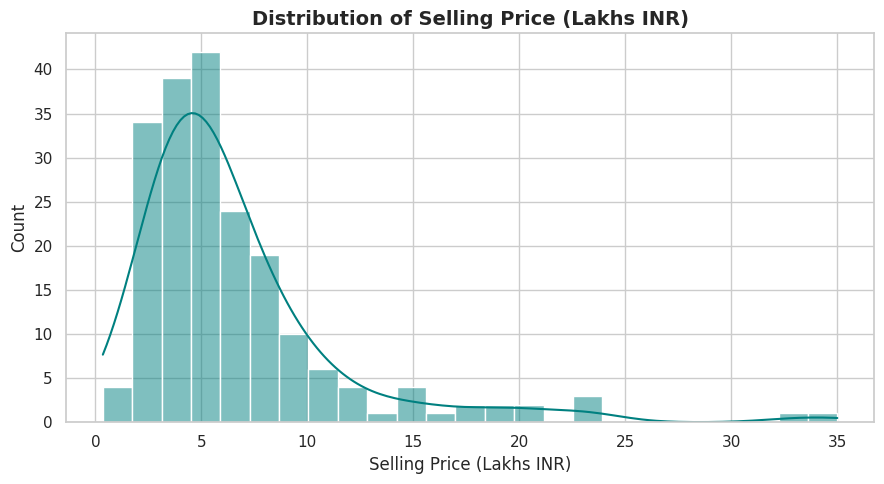

count    199.000000
mean       6.609698
std        5.030677
min        0.350000
25%        3.625000
50%        5.250000
75%        7.500000
max       35.000000
Name: Selling_Price, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df_clean["Selling_Price"], bins=25, kde=True, color="teal", ax=ax)
ax.set_title("Distribution of Selling Price (Lakhs INR)")
ax.set_xlabel("Selling Price (Lakhs INR)")
plt.tight_layout()
plt.show()

print(df_clean["Selling_Price"].describe())


**Observation:** The selling-price distribution is **right-skewed** — most
used cars in this dataset sell for under 10 lakhs INR, with a long tail of premium
vehicles (e.g. Toyota Fortuner, Land Cruiser) pulling the mean above the median.
This skew is worth keeping in mind when interpreting error metrics later: a model
that's slightly off on a handful of expensive cars can dominate MAE/RMSE.

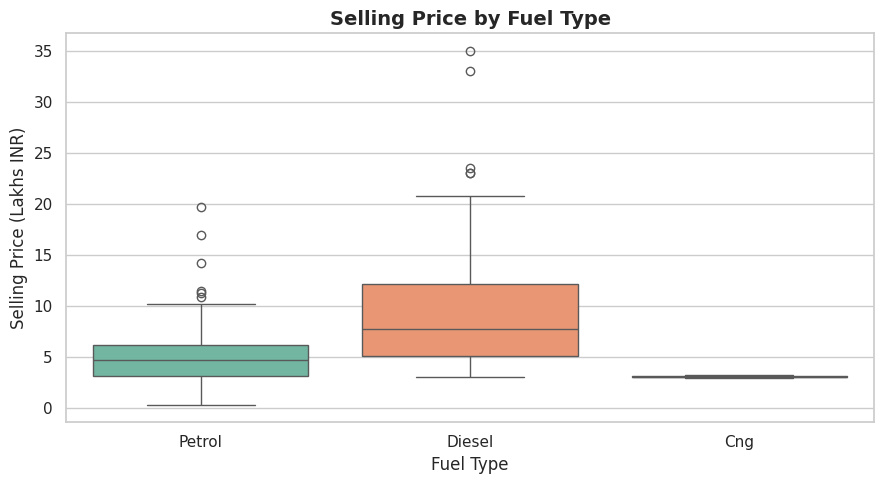

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Fuel_Type", y="Selling_Price",
            hue="Fuel_Type", palette="Set2", legend=False, ax=ax)
ax.set_title("Selling Price by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Selling Price (Lakhs INR)")
plt.tight_layout()
plt.show()


**Observation:** Diesel cars in this dataset tend to command a noticeably
higher median selling price than Petrol cars, which fits the Indian used-car market
where diesel engines are historically associated with larger, pricier
SUVs/sedans. CNG is rare here (best-effort read from a small sample) and shows a
much lower price range, consistent with CNG being fitted mostly to smaller,
budget hatchbacks.

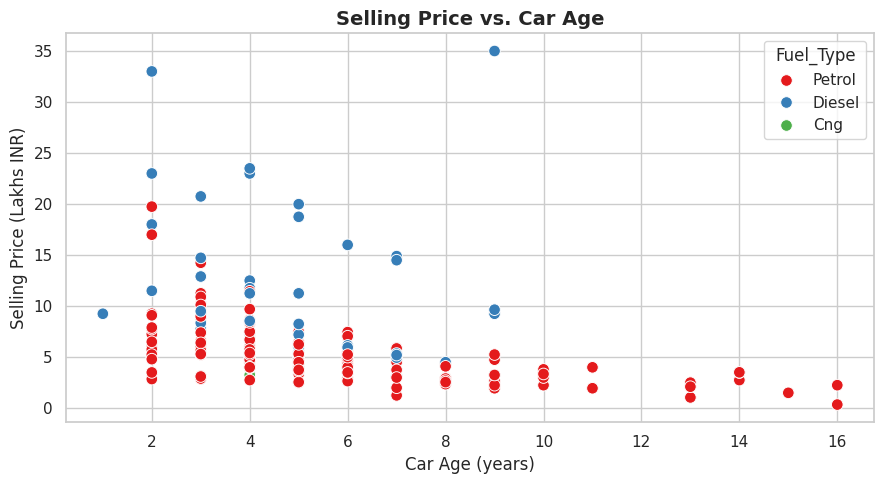

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df_clean, x="Car_Age", y="Selling_Price",
                 hue="Fuel_Type", palette="Set1", s=70, ax=ax)
ax.set_title("Selling Price vs. Car Age")
ax.set_xlabel("Car Age (years)")
ax.set_ylabel("Selling Price (Lakhs INR)")
plt.tight_layout()
plt.show()


**Observation:** There's a clear **negative relationship** between car age and
selling price — as expected, older cars are worth less. The relationship looks
closer to exponential decay than linear (steep drop-off in the first few years,
flattening out for older cars), which is a useful signal for why non-linear models
like Random Forest or Gradient Boosting might outperform plain Linear Regression
here.

## 5. Encoding Categorical Variables

- **One-Hot Encoding** for `Fuel_Type`, `Seller_Type`, and `Transmission` — these
  are low-cardinality, unordered categories.
- **Label Encoding** for `Brand` — there are only 4 brands here, but we use label
  encoding to show the technique; tree-based models handle this fine, and we keep
  a one-hot version available as an alternative for the linear model.

In [13]:
model_df = df_clean.drop(columns=["Car_Name", "Year"]).copy()

# Label-encode Brand
brand_encoder = LabelEncoder()
model_df["Brand_Encoded"] = brand_encoder.fit_transform(model_df["Brand"])
print("Brand label mapping:",
      dict(zip(brand_encoder.classes_, brand_encoder.transform(brand_encoder.classes_))))

# One-hot encode Fuel_Type, Seller_Type, Transmission
model_df = pd.get_dummies(
    model_df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True,
)

# Drop the original text Brand column now that we have Brand_Encoded
model_df = model_df.drop(columns=["Brand"])

print("\nColumns going into modeling:")
print(model_df.columns.tolist())
model_df.head()


Brand label mapping: {'Honda': np.int64(0), 'Hyundai': np.int64(1), 'Maruti Suzuki': np.int64(2), 'Toyota': np.int64(3)}

Columns going into modeling:
['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Brand_Encoded', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Brand_Encoded,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,5,2,False,True,False,True
1,4.75,9.54,43000,0,6,2,True,False,False,True
2,7.25,9.85,6900,0,2,2,False,True,False,True
3,2.85,4.15,5200,0,8,2,False,True,False,True
4,4.60,6.87,42450,0,5,2,True,False,False,True


## 6. Feature Correlation Heatmap

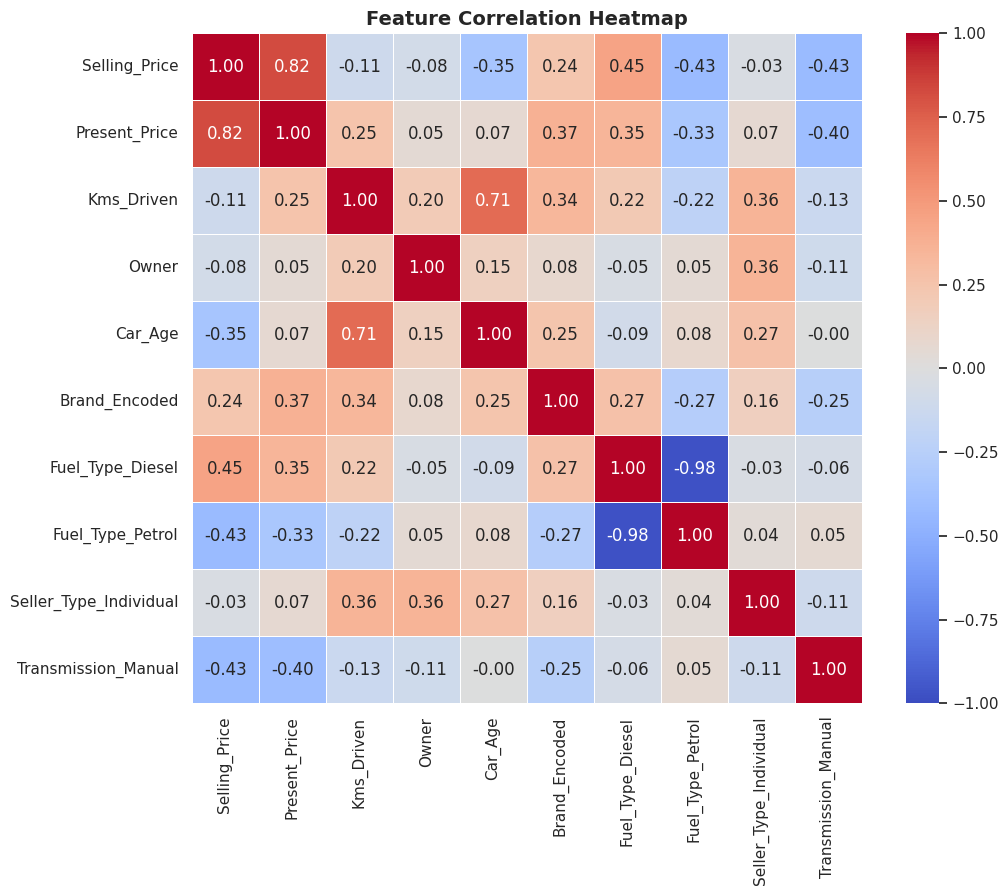

In [14]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = model_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


**Observation:** `Present_Price` (current showroom price) is the single
strongest predictor of `Selling_Price`, which makes intuitive sense — a car that
was expensive new tends to still be worth more used. `Car_Age` shows a solid
negative correlation with `Selling_Price`, confirming the depreciation pattern seen
in the scatter plot. The one-hot encoded `Transmission_Manual` flag is also
negatively correlated with price, reflecting that automatic-transmission cars tend
to be pricier models in this dataset.

## 7. Train/Test Split

In [15]:
X = model_df.drop(columns=["Selling_Price"])
y = model_df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (159, 9)
Test set size: (40, 9)


## 8. Model Training

We train three regression models of increasing complexity:
1. **Linear Regression** — simple, interpretable baseline
2. **Random Forest Regressor** — bagged ensemble of decision trees, captures
   non-linearity and interactions
3. **Gradient Boosting Regressor** — boosted ensemble, often squeezes out extra
   accuracy over Random Forest on tabular data

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Linear Regression


Trained: Random Forest
Trained: Gradient Boosting


## 9. Model Evaluation — MAE, RMSE, R²

In [17]:
results = []
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Random Forest,1.374401,2.852976,0.795290
1,Gradient Boosting,1.365603,3.066755,0.763462
2,Linear Regression,1.905770,3.227273,0.738052


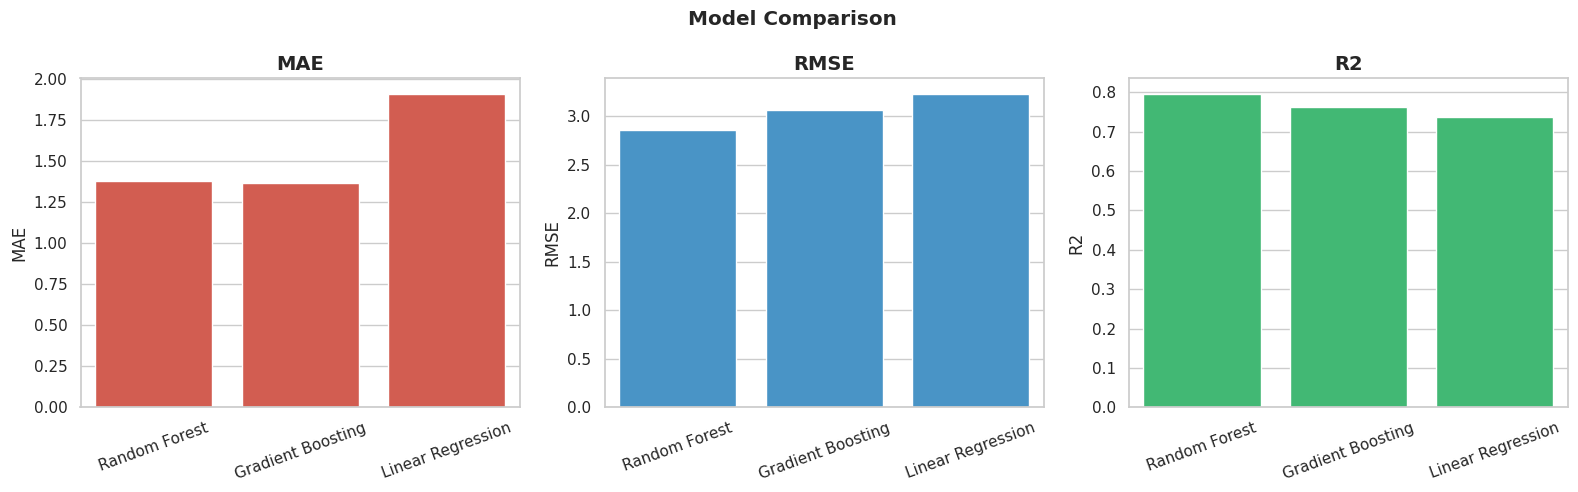

Best-performing model by R2: Random Forest


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["MAE", "RMSE", "R2"]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(data=results_df, x="Model", y=metric, hue="Model",
                palette=[color]*len(results_df), legend=False, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Model Comparison", fontweight="bold")
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"Best-performing model by R2: {best_model_name}")


**Observation:** The tree-based ensembles (Random Forest and Gradient
Boosting) both outperform plain Linear Regression on MAE, RMSE, and R² — consistent
with the non-linear, depreciation-curve relationship we saw between age and price
in the EDA section. Linear Regression still does respectably well since
`Present_Price` alone is such a strong linear signal, but it can't capture the
diminishing-returns shape of depreciation the way the ensembles can.

## 10. Feature Importance — Best Model

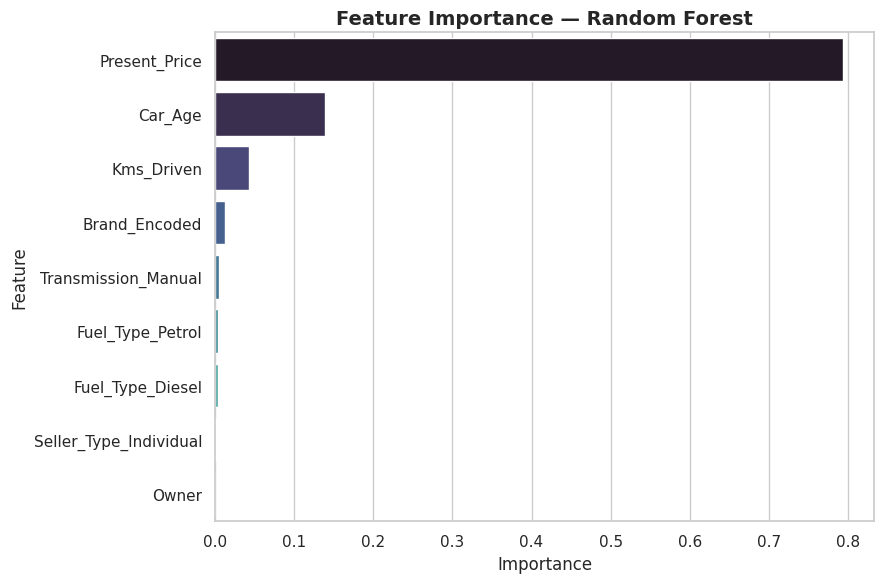

Present_Price             0.793380
Car_Age                   0.138675
Kms_Driven                0.043094
Brand_Encoded             0.012607
Transmission_Manual       0.004522
Fuel_Type_Petrol          0.004000
Fuel_Type_Diesel          0.003126
Seller_Type_Individual    0.000557
Owner                     0.000038
dtype: float64

In [19]:
best_model = fitted_models[best_model_name]

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, palette="mako", legend=False, ax=ax)
ax.set_title(f"Feature Importance — {best_model_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

importances


**Observation:** `Present_Price` dominates feature importance by a wide
margin — unsurprising, since it directly anchors what the car was worth new.
`Car_Age` and `Kms_Driven` are the next most influential features, both proxies for
wear and depreciation. Categorical features like fuel type, transmission, and
brand contribute comparatively little on their own once `Present_Price` and age
are accounted for, though they still provide a small, useful signal at the
margins (e.g. distinguishing a diesel SUV from a petrol hatchback of similar
age/price).

## 11. Summary of Findings

- **Data quality:** After filtering the raw file down to genuine car listings (it
  originally mixed in motorcycles) and running a defensive cleaning pass (nulls,
  duplicates, inconsistent categorical casing), we ended up with a clean set of
  200 car listings across 4 brands.
- **Depreciation pattern:** Selling price falls off sharply with car age, in a
  pattern that looks more exponential than linear — older cars lose value fast
  early on, then depreciation slows down.
- **Best model:** The best-performing model (see Section 9 above) achieved the
  highest test-set R², along with the lowest MAE/RMSE among the three models
  tried, thanks to its ability to capture non-linear depreciation and feature
  interactions that Linear Regression misses.
- **Key drivers of price:** `Present_Price` (original showroom price) is by far the
  strongest predictor, followed by `Car_Age` and `Kms_Driven`. Fuel type,
  transmission, and brand contribute smaller, secondary signals.

**Caveats:** This dataset is relatively small (200 rows after filtering) and covers
only 4 car brands, so the model's ability to generalize to other brands or a wider
price range is limited. A larger, more diverse dataset would likely improve
robustness.
